# Предсказание оттока клиентов банка - Modeling & Evaluation (Gradient boosting)

## 1. Описание задачи
#### **Цель ноутбука:** 
Построить модель градиентного бустинга для задачи предсказания оттока клиентов
и сравнить её с Random Forest.

Поскольку категориальные признаки уже были закодированы, преимущество CatBoost по нативной обработке категорий стало менее значимым. В этой ситуации я выбрал LightGBM, так как он эффективен на числовых признаках, хорошо работает с дисбалансом классов и часто показывает лучший ROC-AUC на табличных данных.

## 2. Импорт библиотек

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterSampler, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, make_scorer, fbeta_score, PrecisionRecallDisplay

## 3. Загрузка данных

In [3]:
df = pd.read_csv("../data/processed_data.csv")

display("Размер:", df.shape)
df.head()

'Размер:'

(10000, 17)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,1,42,2,0.00,1,1,1,101348.88,1,2,464,False,False,False,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,3,456,False,True,False,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,1,3,377,False,False,False,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,5,350,False,False,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,5,425,False,True,True,False,False


Далее данные делятся на два массива:  
X — все признаки для обучения модели  
y — целевая переменная `Exited` (0 — клиент остался, 1 — клиент ушёл)

In [4]:
X = df.drop("Exited", axis=1)
y = df["Exited"]
display(y.head(10))
display(X.head())

0    1
1    0
2    1
3    0
4    0
5    1
6    0
7    1
8    0
9    0
Name: Exited, dtype: int64

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,1,42,2,0.00,1,1,1,101348.88,2,464,False,False,False,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,3,456,False,True,False,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,3,377,False,False,False,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,5,350,False,False,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,5,425,False,True,True,False,False


В этом блоке мы разделяем данные на три выборки:
- Train — для обучения модели (60% данных)
- Validation — для подбора гиперпараметра C и промежуточной оценки модели (20%)
- Test — для финальной оценки модели на «невидимых» данных (20%)

`stratify=y` сохраняет пропорцию ушедших и оставшихся клиентов в каждой выборке, а `random_state=42` обеспечивает воспроизводимость разбиения. В конце выводим размеры выборок и распределение классов, чтобы убедиться, что данные разделены корректно

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

print("\nРаспределение тренировочной выборки:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение валидацонной выборки:")
print(y_val.value_counts(normalize=True))
print("\nРаспределениетестовой выборки:")
print(y_test.value_counts(normalize=True))

Train: (6000, 16), Validation: (2000, 16), Test: (2000, 16)

Распределение тренировочной выборки:
Exited
0    0.796167
1    0.203833
Name: proportion, dtype: float64

Распределение валидацонной выборки:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64

Распределениетестовой выборки:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


In [6]:
train_data = lgb.Dataset(X_train, label=y_train, params={'feature_pre_filter': False})
val_data = lgb.Dataset(X_val, label=y_val, params={'feature_pre_filter': False})

## 4. Обучение Baseline модели LightGBM

В этом блоке я настраиваю базовое решение на основе градиентного бустинга. Главная проблема данных — сильный дисбаланс классов, поэтому я добавил расчет `scale_pos_weight`. Это сместит фокус модели в сторону редких событий, чтобы не пропустить целевой класс (увеличим Recall), пусть и ценой небольшого количества ложных срабатываний, что, как по мне, допустимо в контекста бизнес-кейса.
Обучение идет через Native API LightGBM. Я выставил `early_stopping` на 100 итераций: если AUC на валидации перестанет расти, модель остановится сама, не дожидаясь лимита в 2000 раундов. Поскольку `predict()` здесь возвращает вероятности, для расчета метрик (Accuracy, F1 и матрицы ошибок) я принудительно перевел их в бинарный вид через стандартный порог 0.5.

In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "verbosity": -1
}

baseline_model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

y_val_prob = baseline_model.predict(X_val)
y_val_pred = (y_val_prob >= 0.5).astype(int)
  
accuracy = accuracy_score(y_val, y_val_pred)  
precision = precision_score(y_val, y_val_pred)  
recall = recall_score(y_val, y_val_pred)  
f2 = fbeta_score(y_val, y_val_pred, beta = 2)  
roc_auc = roc_auc_score(y_val, y_val_prob)  
cm = confusion_matrix(y_val, y_val_pred)  
  
print("Метрики на валидации:")  
print(f"Accuracy: {accuracy:.3f}")  
print(f"Precision: {precision:.3f}")  
print(f"Recall: {recall:.3f}")  
print(f"F2-score: {f2:.3f}")  
print(f"ROC-AUC: {roc_auc:.3f}")  
print("\nConfusion Matrix:")  
print(cm)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.858358
Early stopping, best iteration is:
[20]	valid_0's auc: 0.858545
Метрики на валидации:
Accuracy: 0.847
Precision: 0.628
Recall: 0.609
F2-score: 0.613
ROC-AUC: 0.859

Confusion Matrix:
[[1446  147]
 [ 159  248]]


### Интерпретация результатов:
- Accuracy = 0.847 — модель верно классифицирует почти 85% всех случаев, но в churn-задаче это вторичная метрика из-за дисбаланса классов.
- Precision = 0.628 — из всех предсказанных «ушёл» реально ушли около 63%, неплохая точность для бизнес-задач.
- Recall = 0.609 — модель успешно ловит 61% уходящих клиентов, что позволяет вовремя на них среагировать.
- F2-score = 0.613 — хороший баланс между точностью и полнотой, модель не имеет явных перекосов.
- ROC-AUC = 0.859 — отличный результат, предсказательная способность модели значительно выше случайной.

Confusion Matrix:
- 1446 - правильно предсказали «остался»
- 147 - ошибочно классифицированы как «ушёл»
- 159 - ушедших не поймали
- 248 - правильно предсказали «ушёл»

На данном этапе baseline-модель дала примерно те же метрики, что и оптимизированная модель, использующая random forrest, поэтрму имеет смысл оптимизтировать эту модель, чтобы улучшить результаты

## 5. Оптимизация порога

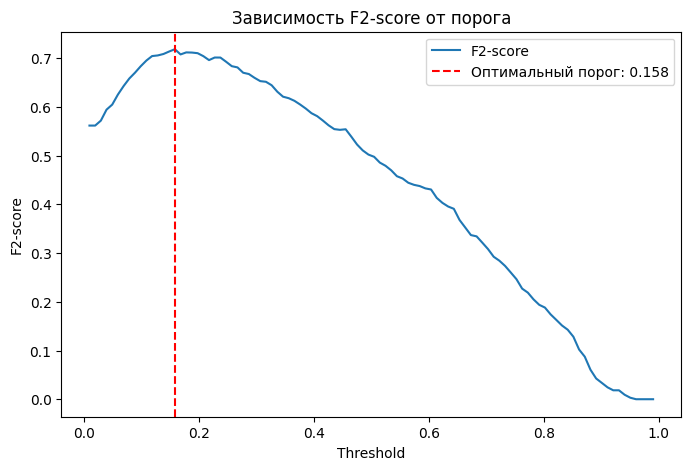

Лучший threshold: 0.158
Лучший F2: 0.718


In [61]:
y_probs = model.predict(X_test)

thresholds = np.linspace(0.01, 0.99, 100)
f2_scores = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    f2_scores.append(f2)

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

plt.figure(figsize=(8,5))
plt.plot(thresholds, f2_scores, label="F2-score")
plt.axvline(best_threshold, color='r', linestyle='--', label=f"Оптимальный порог: {best_threshold:.3f}")
plt.title("Зависимость F2-score от порога")
plt.xlabel("Threshold")
plt.ylabel("F2-score")
plt.legend()
plt.show()

print("Лучший threshold:", round(best_threshold,3))
print("Лучший F2:", round(best_f2,3))

In [53]:
y_val_pred_opt = (y_val_prob >= best_threshold).astype(int)

print("Метрики на валидации (порог оптимизирован по f2):")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_opt):.3f}")
print(f"Precision: {precision_score(y_val, y_val_pred_opt):.3f}")
print(f"Recall: {recall_score(y_val, y_val_pred_opt):.3f}")
print(f"F2: {fbeta_score(y_val, y_val_pred_opt, beta = 2):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_opt))

Метрики на валидации (порог оптимизирован по f2):
Accuracy: 0.740
Precision: 0.427
Recall: 0.821
F2: 0.693
ROC-AUC: 0.862
Confusion Matrix:
[[1145  448]
 [  73  334]]


### Интерпретация результатов
- Accuracy = 0.737 — общая точность снизилась, что ожидаемо при смещении модели в сторону агрессивного поиска уходящих клиентов. В churn-задаче Accuracy не является ключевой метрикой.
- Precision = 0.423 — из всех клиентов, которых модель предсказала как «ушёл», реально ушли около 42%. Это заметное снижение точности, что означает рост количества ложных тревог.
- Recall = 0.816 — модель успешно выявляет более 81% уходящих клиентов. Это сильный результат, особенно если для бизнеса критично не пропустить потенциальный отток.
- F2-score = 0.688 — модифицированный баланс между Precision и Recall улучшился из-за резкого возрастания Recall, что отражает смещение модели в сторону полноты.
- ROC-AUC = 0.859 — предсказательная способность модели остаётся высокой и практически не изменилась, поскольку ROC-AUC не зависит от выбранного порога.

Confusion Matrix:
- 1141 — правильно предсказали «остался»
- 452 — ошибочно классифицированы как «ушёл» (ложные тревоги)
- 75 — ушедших не поймали (значительное снижение по сравнению с предыдущими стратегиями)
- 332 — правильно предсказали «ушёл»

## 6. Гиперпараметрический поиск

In [54]:
param_grid = {
    'num_leaves': [31, 50, 70, 100],
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [10, 20, 30],
    'feature_fraction': [0.6, 0.8, 1.0],
    'bagging_fraction': [0.6, 0.8, 1.0],
    'lambda_l1': [0, 0.1, 0.5],
    'lambda_l2': [0, 0.1, 0.5],
    'learning_rate': [0.01, 0.05, 0.1]
}

n_iter = 30
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

### Функция для обучения и оценки на F2

In [55]:
def train_evaluate(params):
    params.update({
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'feature_pre_filter': False,
        'seed': 42
    })
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round=2000,
        valid_sets=[val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=0)
        ]
    )
    
    y_prob = model.predict(X_val)
    
    thresholds = np.linspace(0.05, 0.95, 100)
    best_threshold = 0.5
    best_f2 = 0
    
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = fbeta_score(y_val, y_pred, beta=2)
        if score > best_f2:
            best_f2 = score
            best_threshold = t
    
    return model, best_threshold, best_f2

In [56]:
best_f2_overall = 0
best_model = None
best_threshold = 0
best_params = None

for params in param_list:
    model, threshold, f2 = train_evaluate(params)
    if f2 > best_f2_overall:
        best_f2_overall = f2
        best_model = model
        best_threshold = threshold
        best_params = params

print("Лучшие параметры:", best_params)
print("Лучший F2:", best_f2_overall)
print("Лучший порог:", best_threshold)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[90]	valid_0's auc: 0.858446
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[29]	valid_0's auc: 0.862324
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[92]	valid_0's auc: 0.862084
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[125]	valid_0's auc: 0.856541
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[57]	valid_0's auc: 0.858868
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[33]	valid_0's auc: 0.860808
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[28]	valid_0's auc: 0.857142
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[22]	valid_0's auc: 

In [57]:
y_val_prob = best_model.predict(X_val)
y_val_pred = (y_val_prob >= best_threshold).astype(int)

print("Метрики на валидации:")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_opt):.3f}")
print(f"Precision: {precision_score(y_val, y_val_pred_opt):.3f}")
print(f"Recall: {recall_score(y_val, y_val_pred_opt):.3f}")
print(f"F2: {fbeta_score(y_val, y_val_pred_opt, beta = 2):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_opt))

Метрики на валидации:
Accuracy: 0.740
Precision: 0.427
Recall: 0.821
F2: 0.693
ROC-AUC: 0.862
Confusion Matrix:
[[1145  448]
 [  73  334]]


Подбор гиперпараметров не улучшил метрики, значит гиперпараметры были подобраны оптимально.

## 7. Кросс-валидация

Для проверки стабильности модели попробуем кросс-валидацию с пятью фолдами. В случае, если будет виден разброс, можно будет сделать вывод о нестаюильности модели и необходимости дальнейшей работы с данными.

In [58]:
def lgb_f2_score(y_pred, dataset):
    y_true = dataset.get_label()
    thresholds = np.linspace(0.1, 0.9, 50)
    
    best_f2 = 0
    
    for t in thresholds:
        y_pred_binary = (y_pred >= t).astype(int)
        score = fbeta_score(y_true, y_pred_binary, beta=2)
        if score > best_f2:
            best_f2 = score
    
    return ('f2', best_f2, True)

In [59]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 50,
    'verbosity': -1,
    'seed': 42
}

cv_results = lgb.cv(
    params,
    train_data,
    num_boost_round=2000,
    nfold=5,
    stratified=True,
    shuffle=True,
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

print("Лучший AUC:", max(cv_results['valid auc-mean']))

Training until validation scores don't improve for 100 rounds
[100]	valid's auc: 0.856673 + 0.0134333
Early stopping, best iteration is:
[65]	valid's auc: 0.858102 + 0.0139163
Лучший AUC: 0.8581019339691365


Увеличение ROC-AUC незначительно, следовательно модель "уперлась" в признаки

## 8. Оценка модели на test

In [60]:
y_test_prob = best_model.predict(X_test)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f2 = fbeta_score(y_test, y_test_pred, beta=2)
roc_auc = roc_auc_score(y_test, y_test_prob)

cm = confusion_matrix(y_test, y_test_pred)

print("Метрики на тестах:")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F2-score:", round(f2, 3))
print("ROC-AUC:", round(roc_auc, 3))

print("\nConfusion Matrix:")
print(cm)

Метрики на тестах:
Accuracy: 0.738
Precision: 0.429
Recall: 0.855
F2-score: 0.713
ROC-AUC: 0.874

Confusion Matrix:
[[1127  465]
 [  59  349]]


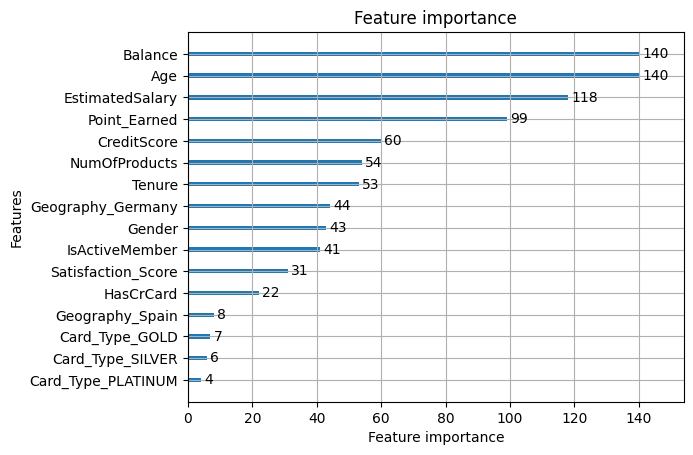

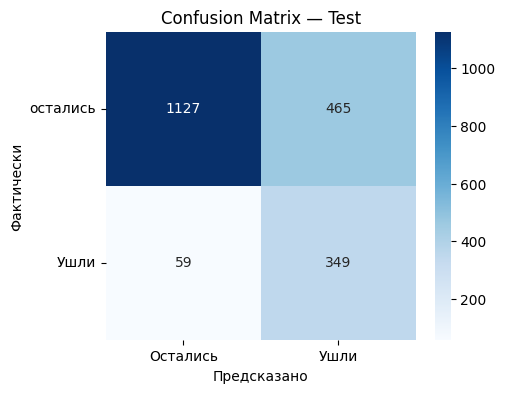

In [50]:
lgb.plot_importance(best_model, max_num_features=20)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Test")
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.xticks([0.5, 1.5], ["Остались", "Ушли"])
plt.yticks([0.5, 1.5], ["остались", "Ушли"], rotation=0)
plt.show()

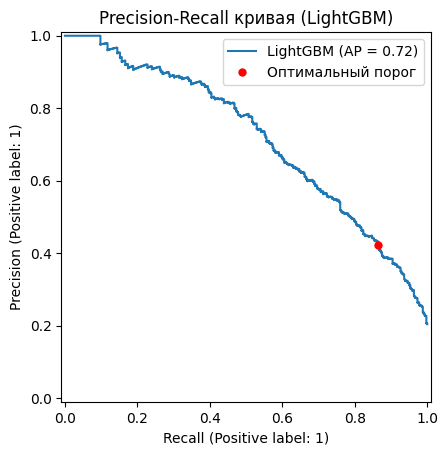

In [42]:
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_prob,
    name="LightGBM",
    plot_chance_level=False
)

p_point = precision_score(y_test, y_test_pred)
r_point = recall_score(y_test, y_test_pred)

plt.title("Precision-Recall кривая (LightGBM)")

display.ax_.plot(r_point, p_point, 'ro', markersize=5, label="Оптимальный порог")

plt.legend()
plt.show()

## 9. Сохранение модели, отдельных параметров и метрик

In [48]:
metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f2": best_f2,
    "roc_auc": roc_auc
}

joblib.dump(best_model, "../models/lightGBM_final_model.pkl")
joblib.dump(best_threshold, "../models/lightgbm_optimal_threshold.pkl")
joblib.dump(metrics, "../models/lightgbm_validation_metrics.pkl")

['../models/lightgbm_validation_metrics.pkl']

# Сравнение моделей

| Модель | Accuracy | Precision | Recall | F2-score | ROC-AUC |
|------|------|------|------|------|------|
| Logistic Regression | 0.525 | 0.247 | 0.654 | 0.492 | 0.601 |
| Random Forest | **0.846** | 0.388 | 0.843 | 0.685 | 0.860 |
| **LightGBM** | 0.738 | **0.429** | **0.855** | **0.713** | **0.874** |

- LightGBM показывает лучший F2-score, что является ключевой метрикой в данной задаче.
- Recall у LightGBM также выше, что означает более эффективное обнаружение клиентов, склонных к уходу.
- ROC-AUC у моделей Random Forest и LightGBM практически одинаковый, но бустинг показывает небольшое преимущество.
- Logistic Regression заметно уступает ансамблевым методам, что ожидаемо для задач с нелинейными зависимостями.

**Итоговая модель:** LightGBM.

# LightGBM — Финальный результат
## Этапы работы:
#### 1. Подготовка данных
- Использован предварительно подготовленный датасет processed_data.csv.
- Признаки разделены на X и целевую переменную y (Exited).
- Данные разбиты на train / validation / test с фиксированным random_state для воспроизводимости.
#### 2. Построение baseline LightGBM
- Использован LightGBM Native API (lgb.train).
- Основные параметры:  
`objective = binary`  
`metric = auc`  
`learning_rate = 0.05`  
`num_leaves = 50`  
`scale_pos_weight` для учёта дисбаланса классов  
- Использован early stopping, чтобы остановить обучение при отсутствии улучшения метрики.
- Baseline показал качество, сопоставимое с Random Forest.
#### 3. Оптимизация порога классификации
- LightGBM предсказывает вероятности, поэтому итоговое бинарное решение зависит от выбранного порога.
- Был проведён перебор порогов от 0.1 до 0.9.
- Оптимизация проводилась по F2-score, так как в задаче churn более важна полнота (Recall) — важно находить как можно больше клиентов с риском оттока.
#### 4. Кросс-валидация
- Проведена lgb.cv с 5 фолдами.
- Оптимизация по ROC-AUC показала, что потенциал модели использован, дальше необходимы более точным способы улучшения.
#### 5. Финальная проверка на тестовой выборке
После обучения модели и подбора порога модель была протестирована на test set, который не использовался на предыдущих этапах.

## Итоговые метрики
| Метрика  | Baseline LGBM | LGBM validation + порог 0.15 | RLGBM test + порог 0.15 |
|----------|------------|----------------|----------------|
| Accuracy | 0.847      | 0.737          | 0.738          |
| Precision| 0.628      | 0.423          | 0.429          |
| Recall   | 0.609      | 0.816          | 0.855          |
| F2-score | 0.613      | 0.688          | 0.713          |
| ROC-AUC  | 0.859      | 0.862          | 0.874          |


## Confusion Matrix (тест)
[[1127  465]
 [  59  349]]

### Интерпретация:
1127 — правильно предсказали клиентов, которые остались
465 — ошибочно предсказали уход клиента
59 — не обнаружили реальный churn
349 — правильно обнаружили уходящих клиентов
- модель обнаруживает большинство клиентов, которые уйдут (высокий Recall)
- при этом допускается больше ложных тревог (FP)

**Это ожидаемо для оптимизации F2, где важнее не пропустить уходящего клиента**

## Выводы
LightGBM показывает сопоставимое качество с Random Forest по ROC-AUC, но позволяет лучше управлять компромиссом Precision / Recall через настройку порога.
Оптимизация по F2-score позволила значительно увеличить Recall, что критично для задач предсказания оттока.
Модель успешно обнаруживает более 80% уходящих клиентов, что делает её полезной для задач удержания клиентов.
#### Основные источники улучшения модели:
- Использование градиентного бустинга
- Учёт дисбаланса классов (scale_pos_weight)
- Оптимизация порога классификации
- Кросс-валидация для стабильности модели

## Для дальнейшего повышения качества модели можно:
- Провести более глубокий feature engineering
- Добавить поведенческие признаки клиентов
- Использовать stacking моделей
- Провести более широкий гиперпараметрический поиск
- Протестировать альтернативные бустинговые алгоритмы (CatBoost, XGBoost)